#  Internship Project
 **The Restaurant Dataset.**
 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("C:/Users/chand/Desktop/intern/Dataset .csv")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)



print("Shape:", df.shape)
print(df.head(51))

print(df.info())


Shape: (9551, 21)
    Restaurant ID                     Restaurant Name  Country Code  \
0             213                      Domino's Pizza             1   
1             355                          New Kadimi             1   
2            4471                    Green Chick Chop             1   
3            9596           Gopal (Sindhi) Restaurant             1   
4            3371                                 BTW             1   
5             214                      Domino's Pizza             1   
6            4450          Jughead's Fast Food Corner             1   
7            5742                             Mehfill             1   
8         6900883                        Ju Ju's Cafe           215   
9        18339373                          Urbanologi           189   
10        7601177          Tuk Tuk Indian Street Food           215   
11       18251260                           Kiss Kiss           148   
12           6261                   Gupta Chat Corner      

## LEVEL 1

### Task 1: Top Cuisines

In [9]:
from collections import Counter

cuisines = df['Cuisines'].dropna().str.split(', ')
cuisine_list = [c for sub in cuisines for c in sub]

cuisine_count = Counter(cuisine_list)

top3 = cuisine_count.most_common(3)
print("Top 3 cuisines:", top3)

# Percentage calculation
total_restaurants = len(df)

for cuisine, count in top3:
    percent = (count / total_restaurants) * 100
    print(cuisine, ":", round(percent,2), "%")


    


Top 3 cuisines: [('North Indian', 3960), ('Chinese', 2735), ('Fast Food', 1986)]
North Indian : 41.46 %
Chinese : 28.64 %
Fast Food : 20.79 %


### Task 2: City Analysis

In [10]:
city_counts = df['City'].value_counts()
print("City with highest restaurants:", city_counts.idxmax())


avg_city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print("Average rating by city")
print(avg_city_rating.head(51))


City with highest restaurants: New Delhi
Average rating by city
City
Inner City                4.900000
Quezon City               4.800000
Makati City               4.650000
Pasig City                4.633333
Mandaluyong City          4.625000
Beechworth                4.600000
London                    4.535000
Taguig City               4.525000
Tagaytay City             4.500000
Secunderabad              4.500000
Lincoln                   4.500000
Orlando                   4.475000
Tampa Bay                 4.410000
Rest of Hawaii            4.410000
Tanunda                   4.400000
Palm Cove                 4.400000
Bangalore                 4.375000
Dubai                     4.370000
Pasay City                4.366667
Jakarta                   4.356250
Hyderabad                 4.344444
Chennai                   4.315000
Ankara                    4.305000
Tangerang                 4.300000
Mohali                    4.300000
Randburg                  4.300000
Sandton              

### Task 3: Price Range Distribution

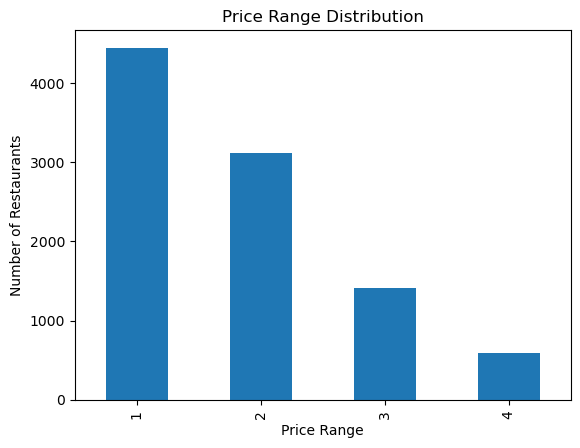

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


In [11]:
price_counts = df['Price range'].value_counts()

price_counts.plot(kind='bar')
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()


price_percent = (price_counts / len(df)) * 100
print(price_percent)


### Task 4: Online Delivery Analysis

In [12]:
online_percent = (df['Has Online delivery'] == 'Yes').mean()*100
print("Percentage offering online delivery:", round(online_percent,2))

rating_compare = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print("Average rating comparison")
print(rating_compare)


Percentage offering online delivery: 25.66
Average rating comparison
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


## LEVEL 2

### Task 1: Restaurant Ratings Distribution

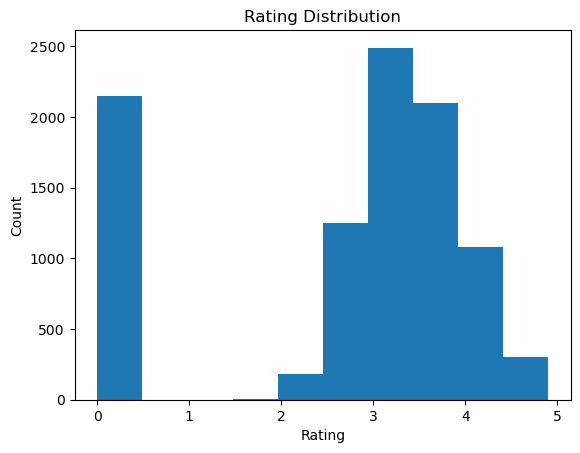

Average votes: 156.909747670401


In [13]:
plt.hist(df['Aggregate rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

avg_votes = df['Votes'].mean()
print("Average votes:", avg_votes)


### Task 2: Cuisine Combination

In [16]:
combo = df['Cuisines'].value_counts()
print("Most common cuisine combinations")
print(combo.head(51))

cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print("Top cuisine combos by rating")
print(cuisine_rating.head(51))


Most common cuisine combinations
Cuisines
North Indian                                936
North Indian, Chinese                       511
Fast Food                                   354
Chinese                                     354
North Indian, Mughlai                       334
Cafe                                        299
Bakery                                      218
North Indian, Mughlai, Chinese              197
Bakery, Desserts                            170
Street Food                                 149
Pizza, Fast Food                            131
Chinese, Fast Food                          118
Mithai, Street Food                         116
South Indian                                112
Bakery, Fast Food                           108
Chinese, North Indian                       105
Mughlai                                     103
Ice Cream, Desserts                          83
Ice Cream                                    74
North Indian, Fast Food                      7

### Task 3: Geographic Analysis

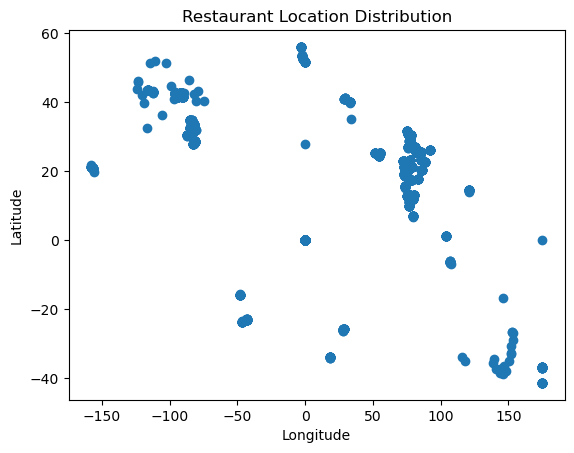

In [18]:
plt.scatter(df['Longitude'], df['Latitude'])
plt.title("Restaurant Location Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Task 4: Restaurant Chains

In [19]:
chains = df['Restaurant Name'].value_counts()

print("Possible restaurant chains")
print(chains.head(51))

chain_rating = df.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)
print("Top chains by rating")
print(chain_rating.head(51))


Possible restaurant chains
Restaurant Name
Cafe Coffee Day            83
Domino's Pizza             79
Subway                     63
Green Chick Chop           51
McDonald's                 48
Keventers                  34
Pizza Hut                  30
Giani                      29
Baskin Robbins             28
Barbeque Nation            26
Giani's                    22
Dunkin' Donuts             22
Barista                    22
Costa Coffee               20
Pind Balluchi              20
Twenty Four Seven          19
Wah Ji Wah                 19
Sagar Ratna                19
Pizza Hut Delivery         19
KFC                        18
Republic of Chicken        18
Chaayos                    18
Starbucks                  18
Burger King                16
Haldiram's                 16
Shree Rathnam              15
Bikanervala                14
Moti Mahal Delux           14
Frontier                   14
Aggarwal Sweets            14
Behrouz Biryani            13
Bikaner Sweets             

## LEVEL 3

### Task 1: Restaurant Reviews Analysis

In [ ]:

if 'Reviews' in df.columns:
    
    df['Review Length'] = df['Reviews'].astype(str).apply(len)
    
    avg_review_len = df['Review Length'].mean()
    print("Average review length:", avg_review_len)
    
    correlation = df[['Review Length','Aggregate rating']].corr()
    print("Correlation between review length and rating")
    print(correlation)
else:
    print("Reviews column not found in dataset")


Reviews column not found in dataset


### Task 2: Votes Analysis

In [20]:
highest_votes = df.loc[df['Votes'].idxmax()]
lowest_votes = df.loc[df['Votes'].idxmin()]

print("Restaurant with highest votes")
print(highest_votes[['Restaurant Name','Votes','Aggregate rating']])

print("Restaurant with lowest votes")
print(lowest_votes[['Restaurant Name','Votes','Aggregate rating']])

correlation = df[['Votes','Aggregate rating']].corr()
print("Correlation between votes and rating")
print(correlation)


Restaurant with highest votes
Restaurant Name      Toit
Votes               10934
Aggregate rating      4.8
Name: 1641, dtype: object
Restaurant with lowest votes
Restaurant Name     Do Bhai Paneer Wale And Sweets
Votes                                            0
Aggregate rating                               0.0
Name: 20, dtype: object
Correlation between votes and rating
                     Votes  Aggregate rating
Votes             1.000000          0.313691
Aggregate rating  0.313691          1.000000


### Task 3: Price Range vs Online Delivery and Table Booking

In [21]:
delivery_price = pd.crosstab(df['Price range'], df['Has Online delivery'])
print("Price range vs Online delivery")
print(delivery_price)

if 'Has Table booking' in df.columns:
    booking_price = pd.crosstab(df['Price range'], df['Has Table booking'])
    print("Price range vs Table booking")
    print(booking_price)


Price range vs Online delivery
Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53
Price range vs Table booking
Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274
